In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, concatenate, Input, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import pandas as pd
import numpy as np
import os

# Définition des chemins de données
DATA_DIR = 'dataset'
ELECTRICAL_DIR = 'donnees_electriques'

TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train')
TRAIN_ELEC_DIR = os.path.join(ELECTRICAL_DIR, 'train')

VALID_IMG_DIR = os.path.join(DATA_DIR, 'valid')
VALID_ELEC_DIR = os.path.join(ELECTRICAL_DIR, 'valid')

# Charger les données électriques (train et valid)
train_elec_data = {}
for cls in ['normal', 'diode', 'hotspot']:
    train_elec_data[cls] = pd.read_csv(os.path.join(TRAIN_ELEC_DIR, cls, f"{cls}_train.csv"))

valid_elec_data = {}
for cls in ['normal', 'diode', 'hotspot']:
    valid_elec_data[cls] = pd.read_csv(os.path.join(VALID_ELEC_DIR, cls, f"{cls}_valid.csv"))

In [7]:
import tensorflow as tf
from tensorflow.keras.utils import Sequence
import pandas as pd
import numpy as np
import os
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

class BimodalDataGenerator(Sequence):
    def __init__(self, img_dir, elec_data_dict, batch_size=32, target_size=(224, 224), shuffle=True):
        self.img_dir = img_dir
        self.elec_data_dict = elec_data_dict
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.classes = ['normal', 'diode', 'hotspot']

        self.data = []
        for i, cls in enumerate(self.classes):
            cls_dir = os.path.join(img_dir, cls)
            elec_df = elec_data_dict[cls]
            filenames = os.listdir(cls_dir)
            filenames.sort()  

            if len(filenames) != len(elec_df):
                raise ValueError(f"Le nombre d'images ({len(filenames)}) ne correspond pas au nombre de lignes dans le fichier CSV ({len(elec_df)}) pour la classe '{cls}'.")
                
            for j, fname in enumerate(filenames):
                img_path = os.path.join(cls_dir, fname)
                elec_features = elec_df.iloc[j][['Voc', 'Isc', 'Vmp', 'Imp', 'Pmax', 'rapport_tension', 'rapport_courant']].values
                self.data.append({
                    'img_path': img_path,
                    'elec_features': elec_features,
                    'label': i
                })

        self.indices = np.arange(len(self.data))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.data) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        
        batch_images = []
        batch_elec_data = []
        batch_labels = []

        for i in batch_indices:
            item = self.data[i]
            
            # Charger et prétraiter l'image
            img = tf.keras.preprocessing.image.load_img(item['img_path'], target_size=self.target_size)
            img = tf.keras.preprocessing.image.img_to_array(img)
            img = preprocess_input(img)
            batch_images.append(img)
            
            # Charger les données électriques
            batch_elec_data.append(item['elec_features'])
            batch_labels.append(item['label'])

        return (np.array(batch_images), np.array(batch_elec_data)), np.array(batch_labels)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# Créer les instances des générateurs
train_generator = BimodalDataGenerator(TRAIN_IMG_DIR, train_elec_data, batch_size=16)
valid_generator = BimodalDataGenerator(VALID_IMG_DIR, valid_elec_data, batch_size=16, shuffle=False)

In [8]:
# Entrées du modèle
image_input = Input(shape=(224, 224, 3), name='image_input')
elec_input = Input(shape=(7,), name='elec_input')

# Branche visuelle
base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)
for layer in base_model.layers:
    layer.trainable = False
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
visual_branch = x

# Branche électrique
y = Dense(64, activation='relu')(elec_input)
y = Dropout(0.5)(y)
y = Dense(32, activation='relu')(y)
elec_branch = y

# Fusion des branches
combined_features = concatenate([visual_branch, elec_branch])

# Couche de classification finale
z = Dense(128, activation='relu')(combined_features)
z = Dropout(0.5)(z)
output = Dense(3, activation='softmax')(z)

# Création du modèle
model = Model(inputs=[image_input, elec_input], outputs=output)

# Compiler le modèle
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Afficher le résumé du modèle
model.summary()

C:\Users\Madj Dp\AppData\Local\Temp\ipykernel_16444\1681397631.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ image_input[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 18,354,531 (70.02 MB)

 Trainable params: 16,096,547 (61.40 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# Entraîner le modèle
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=valid_generator,
    verbose=1
)

# Sauvegarder le modèle entraîné
model_save_path = 'modele_bimodal_solaire_keras.keras'
model.save(model_save_path)
print(f"Modèle sauvegardé sous : {model_save_path}")

# Afficher les performances finales
print(f"Précision finale sur l'ensemble de validation: {history.history['val_accuracy'][-1]:.4f}")

C:\Users\Madj Dp\anaconda3\envs\pv_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6115 - loss: 14.4780 - val_accuracy: 0.9456 - val_loss: 1.1514
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8687 - loss: 2.7970 - val_accuracy: 0.9660 - val_loss: 0.6102
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9238 - loss: 1.9488 - val_accuracy: 0.9796 - val_loss: 0.1302
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9212 - loss: 1.3455 - val_accuracy: 0.9796 - val_loss: 0.1802
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9686 - loss: 0.9027 - val_accuracy: 0.9932 - val_loss: 0.1246
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.9652 - loss: 0.6306 - val_accuracy: 0.9932 - val_loss: 0.1284
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9758 - loss: 0.8820 - val_accuracy: 0.9864 - val_loss: 0.0680
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 893ms/step - accuracy: 0.9724 - loss: 0.4840 - val_accuracy: 0.9932 - val_l

In [10]:
# Précision finale sur validation
val_acc = history.history['val_accuracy'][-1]
train_acc = history.history['accuracy'][-1]

print(f"Précision finale sur entraînement : {train_acc*100:.2f}%")
print(f"Précision finale sur validation : {val_acc*100:.2f}%")

Précision finale sur entraînement : 98.42%
Précision finale sur validation : 98.64%


Extraction des données de validation...
Calcul des prédictions...
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step

--- Rapport de classification ---
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        49
       diode       0.98      0.98      0.98        49
     hotspot       0.98      0.98      0.98        49

    accuracy                           0.99       147
   macro avg       0.99      0.99      0.99       147
weighted avg       0.99      0.99      0.99       147

Rapport de classification sauvegardé sous 'rapport_classification_madj_MobileNetV2.txt'

--- Matrice de confusion ---


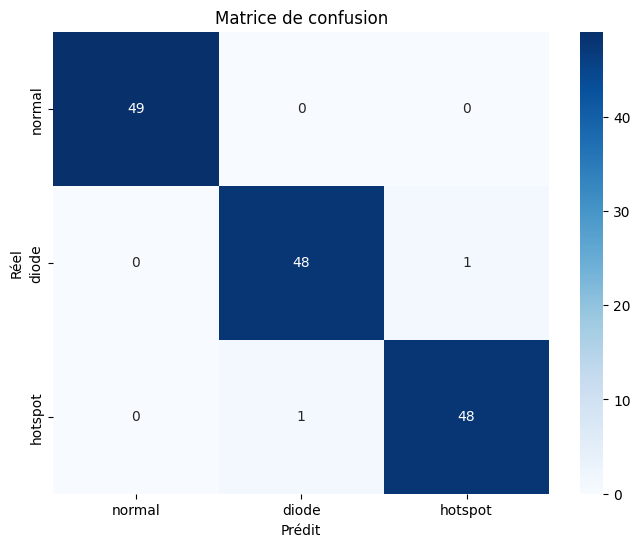


--- Courbes d'entraînement ---


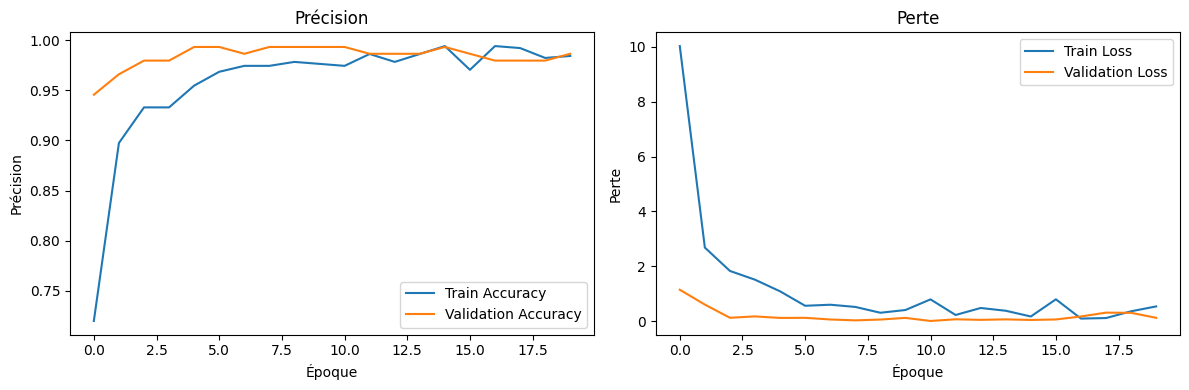


Modèle sauvegardé sous : modele_bimodal_solaire_keras_madj.keras

Processus d'évaluation et de sauvegarde terminé.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import os

# Définition des noms de classes
CLASS_NAMES = ['normal', 'diode', 'hotspot']

# --- Étape 1 : Préparer les données pour les prédictions ---
# Nous devons extraire toutes les données du générateur de validation
# car le modèle.predict() ne peut pas être utilisé directement dessus.
valid_images = []
valid_elec_data = []
valid_labels = []

print("Extraction des données de validation...")
for i in range(len(valid_generator)):
    (images, elec_data), labels = valid_generator[i]
    valid_images.append(images)
    valid_elec_data.append(elec_data)
    valid_labels.append(labels)

# Concaténer les lots en tableaux numpy complets
valid_images = np.vstack(valid_images)
valid_elec_data = np.vstack(valid_elec_data)
valid_labels = np.hstack(valid_labels)

# --- Étape 2 : Prédictions ---
print("Calcul des prédictions...")
# La variable 'model' est celle que vous avez créée et entraînée précédemment.
Y_pred = model.predict([valid_images, valid_elec_data])
y_pred = np.argmax(Y_pred, axis=1)
y_true = valid_labels  # Les labels du générateur sont déjà les bons entiers

# ----------------------------------------
# Rapport de classification
# ----------------------------------------
print("\n--- Rapport de classification ---")
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print(report)

# Sauvegarde du rapport
with open("rapport_classification_madj_MobileNetV2.txt", "w") as f:
    f.write(report)
print("Rapport de classification sauvegardé sous 'rapport_classification_madj_MobileNetV2.txt'")

# ----------------------------------------
# Matrice de confusion
# ----------------------------------------
print("\n--- Matrice de confusion ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de confusion')
plt.savefig('matrice_confusion_madj_MobileNetV2.png', dpi=300)
plt.show()

# ----------------------------------------
# Courbes d'entraînement
# ----------------------------------------
if 'history' in locals():
    print("\n--- Courbes d'entraînement ---")
    def plot_training_curves_madj(history):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
        
        ax1.plot(history.history['accuracy'], label='Train Accuracy')
        ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
        ax1.set_title('Précision')
        ax1.set_xlabel('Époque')
        ax1.set_ylabel('Précision')
        ax1.legend()
        
        ax2.plot(history.history['loss'], label='Train Loss')
        ax2.plot(history.history['val_loss'], label='Validation Loss')
        ax2.set_title('Perte')
        ax2.set_xlabel('Époque')
        ax2.set_ylabel('Perte')
        ax2.legend()
        
        plt.tight_layout()
        plt.savefig('training_curves_madj_MobileNetV2.png')
        plt.show()

    plot_training_curves_madj(history)
else:
    print("L'objet 'history' n'a pas été trouvé. Les courbes d'entraînement ne peuvent pas être tracées.")

# ----------------------------------------
# Sauvegarde du modèle
# ----------------------------------------
model_save_path = "modele_bimodal_solaire_keras_madj.keras"
model.save(model_save_path)
print(f"\nModèle sauvegardé sous : {model_save_path}")

print("\nProcessus d'évaluation et de sauvegarde terminé.")